#Dog Preed Prediction Flask Application


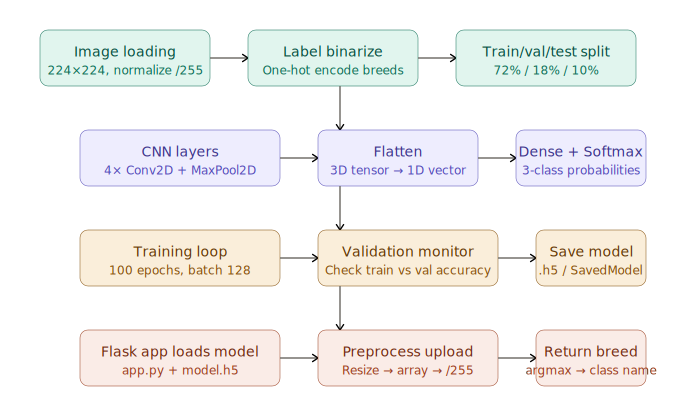

In [14]:
# Convert SVG to PNG so Colab can display it
from IPython.display import SVG, display

with open('/content/dog_dataset/dog_breed_pipeline.svg', 'r') as f:
    svg_content = f.read()

display(SVG(svg_content))

In [15]:
!pip install -q kaggle
#Next, this is the installaiton of the Kaggle api client

In [16]:
# The Kaggle API Client expects this file to be in ~/.kaggle, so move it there.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

# This permissions change avoids a warning on Kaggle tool startup.
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [17]:
#Setting up Kaggle using Kaggle API
!mkdir dog_dataset
%cd dog_dataset

/content/dog_dataset/dog_dataset


In [18]:
!kaggle datasets list -s dogbreedidfromcomp

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [19]:
# Downloading dataset and coming out of directory
!kaggle datasets download catherinehorng/dogbreedidfromcomp

Dataset URL: https://www.kaggle.com/datasets/catherinehorng/dogbreedidfromcomp
License(s): unknown
100% 691M/691M [00:04<00:00, 160MB/s]



In [20]:
#After searching the data next step would be downloading the data into collab notebook using references found in search option.

In [21]:
# Unzipping downloaded file and removing unusable fule
!unzip /content/dog_dataset/dogbreedidfromcomp.zip -d /content/dog_dataset


unzip:  cannot find or open /content/dog_dataset/dogbreedidfromcomp.zip, /content/dog_dataset/dogbreedidfromcomp.zip.zip or /content/dog_dataset/dogbreedidfromcomp.zip.ZIP.


In [22]:
!rm /content/dog_dataset/dogbreedidfromcomp.zip
!rm /content/dog_dataset/sample_submission.csv

rm: cannot remove '/content/dog_dataset/dogbreedidfromcomp.zip': No such file or directory
rm: cannot remove '/content/dog_dataset/sample_submission.csv': No such file or directory


In [23]:
!pip install tensorflow

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from tensorflow.keras.preprocessing import image
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [25]:
import os

# Check where labels.csv actually is
for root, dirs, files in os.walk('/content/dog_dataset'):
    for file in files:
        if file == 'labels.csv':
            print(os.path.join(root, file))

/content/dog_dataset/labels.csv


In [26]:
# Fix the path by pointing to the correct nested location
import pandas as pd
labels_all = pd.read_csv('/content/dog_dataset/labels.csv')
print(labels_all.shape)
labels_all.head()

(10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


**Imported required libraries **

In [27]:
# Read the labels.csv file and checking shape and records
labels_all = pd.read_csv('/content/dog_dataset/labels.csv')
print(labels_all.shape)
labels_all.head()

(10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


# Loading the labels into dataframe and viewing it. Here we analyzed the labels contains 10222 rows and 2 columns.

In [28]:
#Visualize the number of each breeds
breeds_all = labels_all["breed"]
breed_counts = breeds_all.value_counts()
breed_counts.head()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114


In [29]:
#Selecting first 3 breeds (Limitation due to computation power)
CLASS_NAMES = ['scottish_deerhound', 'maltese_dog', 'bernese_mountain_dog']
labels = labels_all[(labels_all['breed'].isin(CLASS_NAMES))]
labels = labels.reset_index()
labels.head()

,index,id,breed
0,9,0042188c895a2f14ef64a918ed9c7b64,scottish_deerhound
1,12,00693b8bc2470375cc744a6391d397ec,maltese_dog
2,79,01e787576c003930f96c966f9c3e1d44,scottish_deerhound
3,90,022b34fd8734b39995a9f38a4f3e7b6b,maltese_dog
4,118,02d54f0dfb40038765e838459ae8c956,bernese_mountain_dog


#Line by Line Explanation

In [30]:
X_data = np.zeros((len(labels), 224, 224, 3), dtype='float32')



###This creates an empty 4D array of zeros.  len(labels) is however many images you have (357 if 3 breeds). Think of it as reserving parking spots before the cars arrive.

#Line 2: Converting breed strings to vectors

In [31]:
Y_data = label_binarize(labels['breed'], classes= CLASS_NAMES)

### Converts breed strings to vectors. Each row becomes [1,0,0], [0,1,0], or [0,0,1] depending on the breed

#Line 3: Loop with progress bar

In [32]:
for i in tqdm(range(len(labels))):
    img = image.load_img('/content/dog_dataset/train/%s.jpg' % labels['id'][i], target_size=(224, 224))
    img = image.img_to_array(img)
    x = np.expand_dims(img.copy(), axis=0)
    X_data[i] = x / 255.0


100%|██████████| 357/357 [00:00<00:00, 660.50it/s]


### Loops through every image index.
###tqdm just wraps the range to show a progress bar
###functionality identical to a plain for loop

###then loads the JPG by filename from

In [33]:
#Printing train image and one hot encode shape & size
print('\nTrain Images shape: ', X_data.shape,' size: {:,}'.format(X_data.size))
print('One-hot encoded output shape: ', Y_data.shape,' size: {:,}'.format(Y_data.size))


Train Images shape:  (357, 224, 224, 3)  size: 53,738,496
One-hot encoded output shape:  (357, 3)  size: 1,071


#Building the Model

In [34]:
model = Sequential()  # Empty container - layers stack in order, output of each feeds into next

# BLOCK 1 - Learns low-level features: edges, fur texture, color boundaries
model.add(Conv2D(filters=64,           # 64 different feature detectors scanning the image
                 kernel_size=(5,5),    # each detector looks at a 5x5 pixel region at a time
                 activation='relu',    # kill negative values, keep positive (one-way valve)
                 input_shape=(224,224,3)))  # 224px wide, 224px tall, 3 color channels (RGB)
model.add(MaxPool2D(pool_size=(2,2)))  # keep only strongest feature per 2x2 region, halves size to 110x110

# BLOCK 2 - Learns mid-level features: eye shapes, ear shapes, snout patterns
model.add(Conv2D(filters=32,           # 32 detectors now (less needed, features already partially extracted)
                 kernel_size=(3,3),    # smaller 3x3 window, looking at finer detail
                 activation='relu',
                 kernel_regularizer='l2'))  # penalize large weights - prevents memorizing training images
model.add(MaxPool2D(pool_size=(2,2)))  # halves size again to 54x54

# BLOCK 3 - Learns higher-level features: face structure, body proportions
model.add(Conv2D(filters=16,           # 16 detectors - further compressed representation
                 kernel_size=(7,7),    # larger 7x7 window - looks at broader spatial relationships
                 activation='relu',
                 kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))  # halves size again to ~24x24

# BLOCK 4 - Learns breed-specific abstract patterns
model.add(Conv2D(filters=8,            # only 8 detectors - highly compressed, abstract features
                 kernel_size=(5,5),
                 activation='relu',
                 kernel_regularizer='l2'))
model.add(MaxPool2D(pool_size=(2,2)))  # final spatial compression, output is roughly 8x8x8

# TRANSITION - Conv layers output 3D, Dense layers need 1D
model.add(Flatten())  # unrolls 8x8x8 cube into a single vector of ~512 numbers

# CLASSIFIER HEAD - learns which feature combinations = which breed
model.add(Dense(128,                   # 128 neurons each connected to every flattened input
                activation='relu',
                kernel_regularizer='l2'))  # still regularizing to prevent overfitting
model.add(Dense(64,                    # compresses further: 128 -> 64 neurons
                activation='relu',
                kernel_regularizer='l2'))

# OUTPUT LAYER - one neuron per dog breed
model.add(Dense(len(CLASS_NAMES),      # 3 neurons (scottish_deerhound, maltese_dog, bernese_mountain_dog)
                activation='softmax')) # converts raw scores to probabilities that sum to 1.0
                                       # e.g. [0.92, 0.05, 0.03] -> 92% scottish deerhound

# COMPILE - defines how the model learns
model.compile(
    loss='categorical_crossentropy',   # measures distance between predicted [0.92,0.05,0.03]
                                       # and true label [1,0,0] - right loss for one-hot encoded data
    optimizer=Adam(0.0001),            # Adam adjusts weights after each batch, 0.0001 = slow/careful
                                       # too fast and Conv filters never learn meaningful patterns
    metrics=['accuracy'])              # report accuracy during training so we can watch progress

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,619 (635.23 KB)

 Trainable params: 162,619 (635.23 KB)

 Non-trainable params: 0 (0.00 B)

## Next we will create a network architecture for thie model. We have used different types of layers according to their features namely Conv_2d (It is used to create a convoloutional kernal that is convolved with the input layer to produce the output tensor), max_pooling2d (It is a downspampling technique which takes out the maximum value over the window defined by poolsize), flatten (It flattens the input and creates 1D output), Dense (Dense layer produce the output as the dot product of the input and kernel)




##After defining the network architecture we found the total parameters as 162,619

In [35]:
#Split off 10% for final tsting - never touched during training
X_train_and_val, X_test, Y_train_and_val, Y_test = train_test_split(X_data, Y_data, test_size=0.1)

#Split remaining 90% into 80% train / 20% validation
X_train, X_val, Y_train, Y_val = train_test_split(X_train_and_val, Y_train_and_val, test_size=0.2)

#Why Split twice?

### The Validation data answers "is this model improving?" during training. Test data answers "how does it actually perform on the data it has never influenced?"

In [36]:
#Training the model

epochs = 10                   # full passes through the training data
batch_size = 128                # images processed before each weight update

history = model.fit(
    X_train, Y_train,           # training data + labels
    batch_size=batch_size,      # feed 128 images at a time
    epochs=epochs,              #  repeats 100 times
    validation_data=(X_val, Y_val)
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step - accuracy: 0.2930 - loss: 4.8960 - val_accuracy: 0.2923 - val_loss: 4.8777
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 0.3672 - loss: 4.8630 - val_accuracy: 0.3231 - val_loss: 4.8506
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3984 - loss: 4.8361 - val_accuracy: 0.2923 - val_loss: 4.8273
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3906 - loss: 4.8118 - val_accuracy: 0.2923 - val_loss: 4.8038
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3867 - loss: 4.7868 - val_accuracy: 0.2923 - val_loss: 4.7799
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 0.3906 - loss: 4.7608 - val_accuracy: 0.2923 - val_loss: 4.7556
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3867 - loss: 4.7350 - val_accuracy: 0.2923 - val_loss: 4.7318
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3867 - loss: 4.7094 - val_accuracy: 0.2923 - val_loss: 4.7057
Epoch 9/

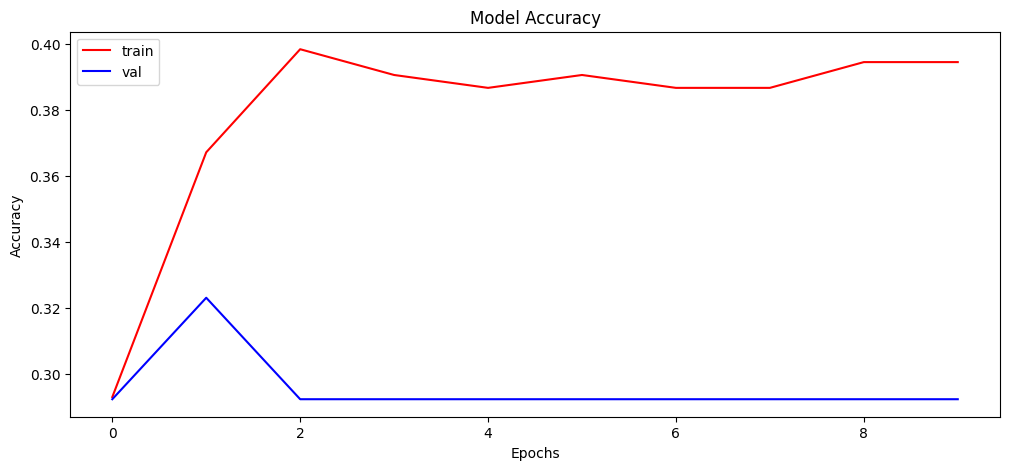

In [37]:
#Plot the training history
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

#Here we analyze how the model is learning with each epoch in terms of accuracy

In [38]:
Y_pred = model.predict(X_test)
score = model.evaluate(X_test, Y_test)
print('Accuracy over the test set: \n ', round((score[1]*100), 2), '%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3889 - loss: 4.6581 
Accuracy over the test set: 
  38.89 %


#We will use predict function to make predictions using this model also we are finding out the accuracy on the test set.

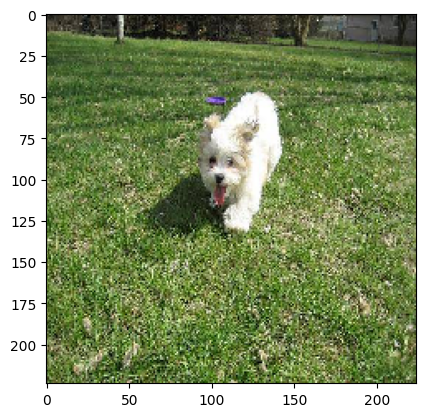

Originally :  maltese_dog


In [39]:
#Plotting image to compare
plt.imshow(X_test[1,:,:,:])
plt.show()

#Finding max value from prediction list and comparing original value vs predicted
print("Originally : ",labels['breed'][np.argmax(Y_test[1])])

In [45]:
print("Predicted : ",labels['breed'][np.argmax(Y_pred[1])])

Predicted :  scottish_deerhound


In [46]:
model.save('/content/dog_breed_model.keras')
print("Saved successfully")

Saved successfully


In [47]:
from google.colab import files
files.download('/content/dog_breed_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>